<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>PCA From Scratch</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Go through the PCA steps one by one, by hand</li>
<li>Turn each step into its own small function so it is reusable</li>
<li>Track the explained variance ratio of each component</li>
<li>Check our result against sklearn to make sure it is correct</li>
</ol>
In the last notebook i built the intuition, variance is information and principal components are the directions of maximum variance. Now i will turn those steps into actual code. I am not using sklearn for the algorithm itself, only at the very end to verify.
</div>

In [1]:
# only numpy and matplotlib for the algorithm, sklearn is used at the end just to verify

import numpy as np
import matplotlib.pyplot as plt

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Quick recap of the steps</b>
</h2>
<div style="font-family:'Times New Roman';">
To reduce data from n features down to k features:
<ol>
<li>standardize so every feature has mean 0 and std 1</li>
<li>build the covariance matrix from the standardized data</li>
<li>find the eigenvalues and eigenvectors of it (the eigenvectors are the principal components, the eigenvalues are the variance along each one)</li>
<li>sort the eigenvectors by eigenvalue, biggest first</li>
<li>keep the top k eigenvectors as the columns of a matrix W</li>
<li>project the data, Z = X_std W</li>
</ol>
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Part 1 doing it by hand once</b>
</h2>
<div style="font-family:'Times New Roman';">
Before making functions let me just do the whole thing once on a small dataset so the steps are clear.
</div>

In [2]:
# small correlated 2d dataset
np.random.seed(42)

mean = [3, 5]
cov = [[3, 2.5],
       [2.5, 3]]

X = np.random.multivariate_normal(mean, cov, 200)
print("Data shape:", X.shape)

Data shape: (200, 2)


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Step 1 standardize the data</b>
</h2>
<div style="font-family:'Times New Roman';">
We subtract the mean and divide by the standard deviation of each feature so every feature ends up with mean 0 and std 1. This stops a feature from looking important just because its numbers are big.
</div>

In [3]:
mean_vec = X.mean(axis=0)
std_vec = X.std(axis=0)

X_std = (X - mean_vec) / std_vec

print("Mean after standardizing:", X_std.mean(axis=0).round(4))
print("Std after standardizing :", X_std.std(axis=0).round(4))

Mean after standardizing: [-0.  0.]
Std after standardizing : [1. 1.]


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Step 2 covariance matrix</b>
</h2>
<div style="font-family:'Times New Roman';">
The covariance matrix tells how the features change together. The diagonal is the variance of each feature and the off diagonal values show how two features move together. PCA reads this matrix to find the directions of maximum variance.
</div>

In [4]:
# rowvar=False means each column is treated as a feature
cov_matrix = np.cov(X_std, rowvar=False)
print("Covariance matrix:\n", cov_matrix.round(3))

Covariance matrix:
 [[1.005 0.835]
 [0.835 1.005]]


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Step 3 eigenvalues and eigenvectors</b>
</h2>
<div style="font-family:'Times New Roman';">
The eigenvectors of the covariance matrix are the principal component directions and each eigenvalue is the variance along its eigenvector. I am using np.linalg.eigh because the covariance matrix is symmetric.
</div>

In [5]:
eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)

print("Eigenvalues:", eig_vals.round(3))
print("Eigenvectors:\n", eig_vecs.round(3))

Eigenvalues: [0.17 1.84]
Eigenvectors:
 [[ 0.707 -0.707]
 [-0.707 -0.707]]


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Step 4 sort by eigenvalue</b>
</h2>
<div style="font-family:'Times New Roman';">
eigh gives the eigenvalues in increasing order so i flip them to put the most important component (highest variance) first.
</div>

In [6]:
order = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[order]
eig_vecs = eig_vecs[:, order]

print("Sorted eigenvalues:", eig_vals.round(3))

explained = eig_vals / eig_vals.sum()
for i, r in enumerate(explained):
    print(f"PC{i+1} keeps {r*100:.2f}% of variance")

Sorted eigenvalues: [1.84 0.17]
PC1 keeps 91.56% of variance
PC2 keeps 8.44% of variance


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Step 5 and 6 pick top k and project</b>
</h2>
<div style="font-family:'Times New Roman';">
To go down to k dimensions i keep the first k eigenvectors as the columns of a matrix W and then project the standardized data onto them, Z = X_std W.
</div>

In [7]:
k = 1
W = eig_vecs[:, :k]      # projection matrix with the top k components
Z = X_std @ W            # reduced data

print("Reduced data shape:", Z.shape)
print("First 5 projected values:\n", Z[:5].round(3))

Reduced data shape: (200, 1)
First 5 projected values:
 [[ 0.694]
 [ 0.913]
 [-0.342]
 [ 2.23 ]
 [-0.672]]


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Part 2 putting each step into a function</b>
</h2>
<div style="font-family:'Times New Roman';">
Doing all of that by hand every time is annoying, so let me make a small function for each step. Then i can just call them in order.
</div>

In [8]:
def standardize(X):
    # subtract mean and divide by std for each feature
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    X_std = (X - mean) / std
    return X_std, mean, std

In [9]:
def covariance_matrix(X_std):
    # each column is a feature
    return np.cov(X_std, rowvar=False)

In [10]:
def get_principal_components(cov_matrix, n_components):
    # eigen decomposition of the covariance matrix
    eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)

    # sort biggest eigenvalue first
    order = np.argsort(eig_vals)[::-1]
    eig_vals = eig_vals[order]
    eig_vecs = eig_vecs[:, order]

    # keep only the top components
    components = eig_vecs[:, :n_components]
    explained_ratio = eig_vals[:n_components] / eig_vals.sum()
    return components, explained_ratio

In [11]:
def project(X, mean, std, components):
    # standardize using the mean and std we already found, then project
    X_std = (X - mean) / std
    return X_std @ components

In [12]:
def reconstruct(Z, components, mean, std):
    # go back from the reduced space to the original space (approx if we dropped components)
    X_std = Z @ components.T
    return X_std * std + mean

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Using the functions</b>
</h2>
<div style="font-family:'Times New Roman';">
Now lets run PCA on the data using these functions and keep both components.
</div>

In [13]:
X_std, mean, std = standardize(X)
cov_matrix = covariance_matrix(X_std)
components, explained_ratio = get_principal_components(cov_matrix, n_components=2)

Z = project(X, mean, std, components)

print("Components (principal directions):\n", components.round(3))
print("\nExplained variance ratio:", explained_ratio.round(4))
print(f"Total variance kept by 2 PCs: {explained_ratio.sum()*100:.2f}%")

Components (principal directions):
 [[-0.707  0.707]
 [-0.707 -0.707]]

Explained variance ratio: [0.9156 0.0844]
Total variance kept by 2 PCs: 100.00%


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Visualizing the transformed data</b>
</h2>
<div style="font-family:'Times New Roman';">
After PCA the data is written along PC1 and PC2. Notice how the cloud is now lined up with the axes, PC1 (the x axis) has the most spread, PC2 (the y axis) has less, and the correlation we started with is gone.
</div>

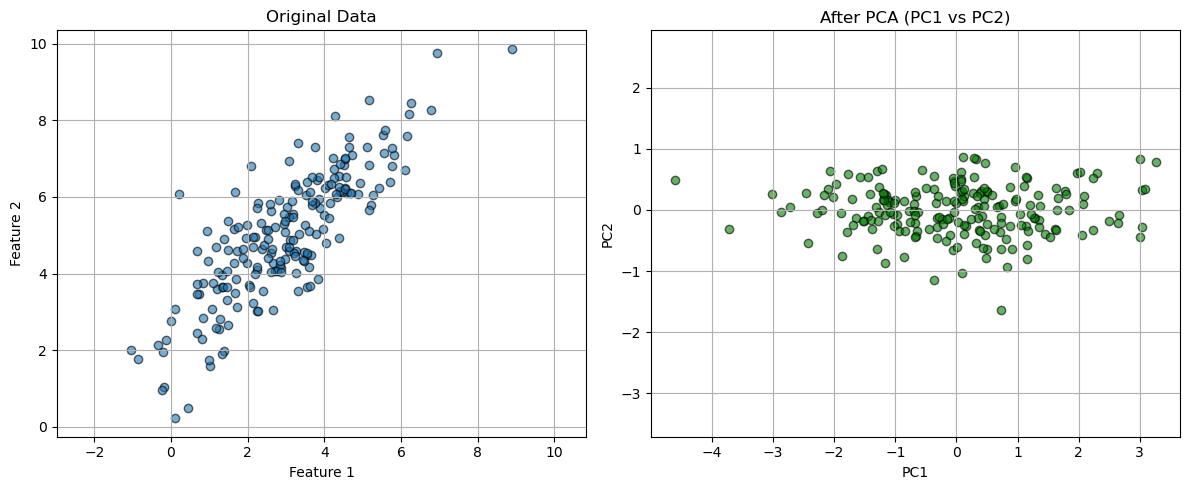

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X[:, 0], X[:, 1], alpha=0.6, edgecolors='k')
axes[0].set_title("Original Data")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].axis('equal')
axes[0].grid(True)

axes[1].scatter(Z[:, 0], Z[:, 1], alpha=0.6, edgecolors='k', color='green')
axes[1].set_title("After PCA (PC1 vs PC2)")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].axis('equal')
axes[1].grid(True)

plt.tight_layout()
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Reconstructing the data</b>
</h2>
<div style="font-family:'Times New Roman';">
Since PCA is linear we can map the reduced data back to the original space. If we kept fewer components the reconstruction is only approximate and the gap is exactly the information we decided to drop.
</div>

In [15]:
# reduce to 1 component then try to rebuild the original 2d data
X_std, mean, std = standardize(X)
cov_matrix = covariance_matrix(X_std)
components_1d, explained_1d = get_principal_components(cov_matrix, n_components=1)

Z_1d = project(X, mean, std, components_1d)
X_rebuilt = reconstruct(Z_1d, components_1d, mean, std)

reconstruction_error = np.mean((X - X_rebuilt) ** 2)
print(f"Reconstruction error with 1 component: {reconstruction_error:.4f}")
print(f"Variance kept by 1 component: {explained_1d[0]*100:.2f}%")

Reconstruction error with 1 component: 0.2315
Variance kept by 1 component: 91.56%


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Checking against sklearn</b>
</h2>
<div style="font-family:'Times New Roman';">
Always good to double check. Lets compare with sklearn. The sign of the components can come out flipped (that is fine, an axis and its opposite are the same line) but the explained variance ratios should be basically the same.
</div>

In [16]:
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(X)
sk_pca = SklearnPCA(n_components=2)
sk_pca.fit(X_scaled)

print("Our explained variance ratio    :", explained_ratio.round(4))
print("sklearn explained variance ratio:", sk_pca.explained_variance_ratio_.round(4))

Our explained variance ratio    : [0.9156 0.0844]
sklearn explained variance ratio: [0.9156 0.0844]


<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>Went through all 6 PCA steps by hand, standardize, covariance, eigen decomposition, sort, pick, project</li>
<li>Made a small function for each step instead of one big class, so they are easy to reuse</li>
<li>Used the explained variance ratio to see how much information each component keeps</li>
<li>Saw that dropping to fewer components gives a small reconstruction error</li>
<li>Checked our result against sklearn and the explained variance ratios matched</li>
</ul>
Next i will use PCA on a real dataset, the Iris data, to bring 4 features down to 2 and plot all three species in one scatter.
</div>